# Module 1 — Consensus Outlier Removal

Combine outlier flags from ABOD, IEF, LODA, LOF. Drop rows flagged by at least 2 of 4 methods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../processed_data/cmi_preprocessed.csv', index_col='id')
print(f'Base shape: {df.shape}')
df.head()

Base shape: (8259, 19)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,
0,5.0,0,51.0,116.840000,23.042474,84.333333,2.0,16.8792,1492.00,41.5862,13.817700,3.06143,1.0,3.0,2.0,82.555556,2.123081,3,2.500000
1,9.0,0,60.5,121.920000,20.865232,70.000000,2.0,14.0371,1498.65,42.0291,12.825400,1.21172,1.0,0.0,0.0,90.666667,0.828527,4,2.175000
2,10.0,1,71.0,143.510000,34.291555,94.000000,3.0,17.9665,1863.98,61.0662,14.092500,3.69863,2.0,2.0,0.0,82.333333,5.546522,5,2.088333
3,9.0,0,71.0,142.240000,37.013107,97.000000,3.0,18.2943,1923.44,62.7757,14.074000,4.22033,2.0,0.0,1.0,79.000000,6.967458,4,2.230500
4,18.0,1,65.0,137.862733,34.926584,89.000000,3.0,17.9665,1863.98,61.0662,15.141363,3.69863,2.0,1.0,0.0,83.388889,5.649235,5,1.885000


In [3]:
abod = pd.read_csv('../../outlier_data/abod.csv', index_col=0)
ief  = pd.read_csv('../../outlier_data/eif.csv',  index_col=0)
loda = pd.read_csv('../../outlier_data/loda.csv', index_col=0)
lof  = pd.read_csv('../../outlier_data/lof.csv',  index_col=0)

for name, d in [('abod', abod), ('ief', ief), ('loda', loda), ('lof', lof)]:
    print(f'{name}: shape={d.shape}, outliers={int(d["is_outlier"].sum())}')

abod: shape=(8259, 12), outliers=83
ief: shape=(8259, 21), outliers=83
loda: shape=(8259, 12), outliers=83
lof: shape=(8259, 12), outliers=83


In [4]:
# All 4 outputs share positional order with the base dataset (same source, same row count).
assert len(abod) == len(ief) == len(loda) == len(lof) == len(df)

votes = pd.DataFrame({
    'abod': abod['is_outlier'].values,
    'ief':  ief['is_outlier'].values,
    'loda': loda['is_outlier'].values,
    'lof':  lof['is_outlier'].values,
}, index=df.index)
votes['n_votes'] = votes.sum(axis=1)
votes['n_votes'].value_counts().sort_index()

n_votes
0    8038
1     165
2      22
3      13
4      21
Name: count, dtype: int64

In [5]:
# Pairwise overlap between methods
methods = ['abod', 'ief', 'loda', 'lof']
overlap = pd.DataFrame(index=methods, columns=methods, dtype=int)
for a in methods:
    for b in methods:
        overlap.loc[a, b] = int(((votes[a] == 1) & (votes[b] == 1)).sum())
overlap

,abod,ief,loda,lof
abod,83.0,33.0,29.0,33.0
ief,33.0,83.0,27.0,35.0
loda,29.0,27.0,83.0,30.0
lof,33.0,35.0,30.0,83.0


In [6]:
consensus_mask = votes['n_votes'] >= 2
n_drop = int(consensus_mask.sum())
print(f'Rows flagged by >=2 methods: {n_drop} / {len(df)} ({n_drop/len(df)*100:.2f}%)')

Rows flagged by >=2 methods: 56 / 8259 (0.68%)


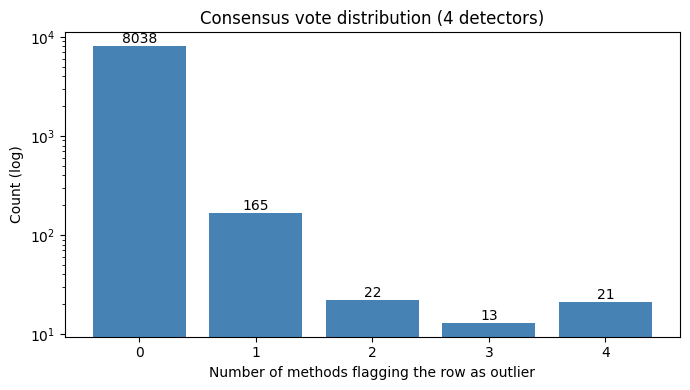

In [7]:
vc = votes['n_votes'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index.astype(str), vc.values, color='steelblue')
ax.set_xlabel('Number of methods flagging the row as outlier')
ax.set_ylabel('Count (log)')
ax.set_yscale('log')
for i, v in enumerate(vc.values):
    ax.text(i, v, str(int(v)), ha='center', va='bottom')
ax.set_title('Consensus vote distribution (4 detectors)')
plt.tight_layout()
plt.show()

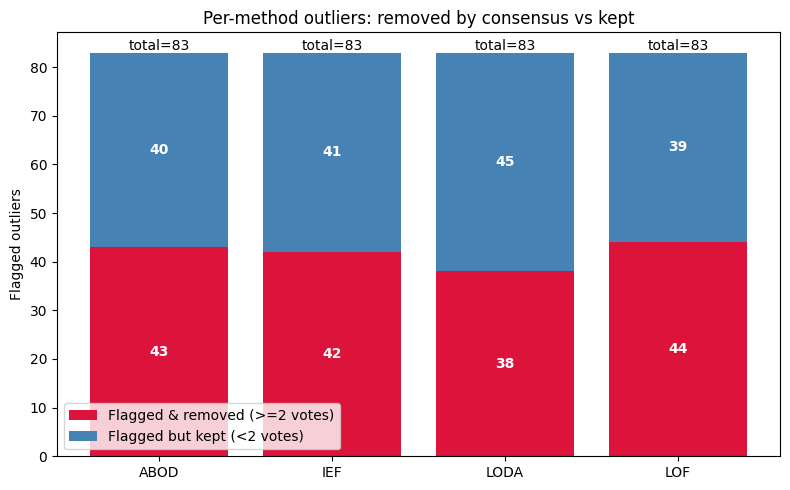

In [8]:
methods = ['abod', 'ief', 'loda', 'lof']
totals = [int(votes[m].sum()) for m in methods]
removed = [int(((votes[m] == 1) & consensus_mask).sum()) for m in methods]
kept = [t - r for t, r in zip(totals, removed)]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods))
ax.bar(x, removed, color='crimson', label='Flagged & removed (>=2 votes)')
ax.bar(x, kept, bottom=removed, color='steelblue', label='Flagged but kept (<2 votes)')

for i, (r, k, t) in enumerate(zip(removed, kept, totals)):
    if r: ax.text(i, r/2, str(r), ha='center', va='center', color='white', fontweight='bold')
    if k: ax.text(i, r + k/2, str(k), ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, t, f'total={t}', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in methods])
ax.set_ylabel('Flagged outliers')
ax.set_title('Per-method outliers: removed by consensus vs kept')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
df_clean = df.loc[~consensus_mask].copy()
print(f'Clean shape: {df_clean.shape}')
df_clean.to_csv('../../outlier_data/cmi_consensus_clean.csv')
df_clean.head()

Clean shape: (8203, 19)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,
0,5.0,0,51.0,116.840000,23.042474,84.333333,2.0,16.8792,1492.00,41.5862,13.817700,3.06143,1.0,3.0,2.0,82.555556,2.123081,3,2.500000
1,9.0,0,60.5,121.920000,20.865232,70.000000,2.0,14.0371,1498.65,42.0291,12.825400,1.21172,1.0,0.0,0.0,90.666667,0.828527,4,2.175000
2,10.0,1,71.0,143.510000,34.291555,94.000000,3.0,17.9665,1863.98,61.0662,14.092500,3.69863,2.0,2.0,0.0,82.333333,5.546522,5,2.088333
3,9.0,0,71.0,142.240000,37.013107,97.000000,3.0,18.2943,1923.44,62.7757,14.074000,4.22033,2.0,0.0,1.0,79.000000,6.967458,4,2.230500
4,18.0,1,65.0,137.862733,34.926584,89.000000,3.0,17.9665,1863.98,61.0662,15.141363,3.69863,2.0,1.0,0.0,83.388889,5.649235,5,1.885000
